In [ ]:
# Copyright 2025 United Kingdom Research and Innovation
# Copyright 2025 The University of Manchester
# Copyright 2025 Technical University of Denmark
#
# Authors:
#   David Wang Johansen, s214743@dtu.dk
#   Martin Sæbye Carøe, msaca@dtu.dk
#   Rasmus Juul Pedersen, rjupe@dtu.dk
#
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#     http://www.apache.org/licenses/LICENSE-2.0
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# NSI helical scan reconstruction using CIL

In this notebook, we demonstrate how the CORE IMEGING LIBRARY (CIL) can be used to do tomographic reconstruction of a scan taken in a helical setup. The sample is a "Babe Ruth" chocolate bar, and the data was acquired with an NSI VorteX CT scanner: https://4nsi.com/advantages-of-scanning-with-vortex/

In [3]:
import os
from pathlib import Path, PureWindowsPath

import numpy as np
import matplotlib.pyplot as plt

from cil.framework import AcquisitionData, AcquisitionGeometry, ImageGeometry
from cil.io.TIFF import TIFFStackReader
from cil.utilities.display import show2D, show_geometry, show_system_positions
from cil.utilities.jupyter import islicer
from cil.processors import TransmissionAbsorptionConverter, Normaliser
from cil.plugins.astra import FBP
import tifffile

### CIL version 25.0.0

In [4]:
import cil
print(cil.__version__)

25.0.0


### The Dataset

The dataset used in this notebook can be downloaded here:


Please set the BASE_PATH to the directory of the .nsipro configurations file

In [5]:
BASE_PATH = Path("/work3/s164564/CIL-Reader-Showcase/data/NSI-data")
FILE_NAME = "Demo_BabeRuth - PreReconstruction.nsipro"
META_PATH = BASE_PATH / FILE_NAME
POSITIONS_PATH = BASE_PATH / "Radiographs-Demo_BabeRuth/positions.txt"

The dataset contains transmission images, however no flat or dark field images are provided. We use an empty transmission image (outside the field of view of the sample) as a flat field image.

The geometry of the scan is inferred from the configurations file. We read in the metadata with the $\verb!parse_geometry!$ function

In [6]:
def parse_nsipro(file_name):
    with open(file_name, 'r') as f:
        text = f.read()
    lines = [line.rstrip() for line in text.splitlines() if line.strip()]
    root = {}
    stack = [(root, None)]
    
    for line in lines:
        indent = len(line) - len(line.lstrip())
        content = line.strip()
        while len(stack) > indent // 2 + 1:
            stack.pop()
        
        current_dict, current_key = stack[-1]
        
        if content.startswith("</"):
            continue
        
        if content.startswith("<") and ">" in content:
            tag = content[1:content.find(">")]
            value = content[content.find(">")+1:].strip()
            
            if value:
                current_dict[tag] = value
            else:
                if tag in current_dict:
                    if not isinstance(current_dict[tag], list):
                        current_dict[tag] = [current_dict[tag]]
                    new_dict = {}
                    current_dict[tag].append(new_dict)
                else:
                    new_dict = {}
                    current_dict[tag] = new_dict
                stack.append((new_dict, tag))
    
    return root

In [7]:
metadata = parse_nsipro(META_PATH)['NSI Reconstruction Project']

In a helical scan setup with the NSI VorteX CT scanner, the object rotates on a stage. The source and detector simultaneously move vertically. This allows for scanning objects that are longer than the detector height. The detector also jitters during the scan: Between each projection, the detector moves a small random but known amount. This limits ring artifacts from bad pixels, but must be accounted for during reconstruction. 
The geometry of each projection is similar to a regular cone-beam setup.

In [8]:
height = float(metadata['VorteX']['height'])
height_per_rev = float(metadata['VorteX']['pitch'])
revs = float(metadata['VorteX']['revolutions'])
N_projections = int(metadata['Object Radiograph']['number'])
angle_step = float(metadata['Object Radiograph']['angleStep'])
mm_per_micron = 0.001
pixel_size_w = mm_per_micron*float(metadata['CT Project Configuration']['Technique Configuration']['Detector']['pixel width microns'])
pixel_size_h = mm_per_micron*float(metadata['CT Project Configuration']['Technique Configuration']['Detector']['pixel height microns'])
pixel_num_w =  metadata['CT Project Configuration']['Technique Configuration']['Detector']['width pixels']
pixel_num_h =  metadata['CT Project Configuration']['Technique Configuration']['Detector']['height pixels']
src_to_det = float(metadata['CT Project Configuration']['Technique Configuration']['Setup']['source to detector distance'])
src_to_obj = float(metadata['CT Project Configuration']['Technique Configuration']['Setup']['source to table distance'])




print('Height of scan in mm:', height)
print('Vertical detector+source movement per sample rotation in mm: ', height_per_rev)
print('Total number of sample rotations: ', revs)

print('Number of projections: ', N_projections)
print('Angular step between projections in degrees: ', angle_step)

print('Pixel width in mm:', pixel_size_w)
print('Pixel height in mm: ',pixel_size_h)
print('Number of detector pixels in the horizontal direction: ', pixel_num_w)
print('Number of detector pixels in the vertical direction: ', pixel_num_h)

print('Source to detector distance in mm: ', src_to_det)
print('Source to sample distance in mm', src_to_obj)

Height of scan in mm: 180.13045
Vertical detector+source movement per sample rotation in mm:  15.0108708333333
Total number of sample rotations:  12.0
Number of projections:  4320
Angular step between projections in degrees:  0.999306037473976
Pixel width in mm: 0.2
Pixel height in mm:  0.2
Number of detector pixels in the horizontal direction:  1536
Number of detector pixels in the vertical direction:  1536
Source to detector distance in mm:  1258.54
Source to sample distance in mm 257.047


## Reading the datafiles

The relative paths for the data is also given in the metadata. For the purpose of this notebook, we only read in a subset of the data, corresponding to the first 5 sample rotations.

In [10]:
tiff_directory_path = (Path(META_PATH).parent / PureWindowsPath(metadata['Object Radiograph']['file'])).parent

num_proj_subset = 5*360

roi = {'axis_0': (None, num_proj_subset, None), 'axis_1': -1, 'axis_2': -1}
tiff_reader = TIFFStackReader(file_name=tiff_directory_path, roi=roi)
data = tiff_reader.read()[:,:,:]

Since there are no flat field images provided in the dataset, we load in the last projection (which is outside the field of view of the sample) and use that as the flat field.

In [11]:
flat_field = np.array(tifffile.imread(META_PATH.parent / 'Radiographs-Demo_BabeRuth/Demo_BabeRuth-radio_04319.tif'))[:,:]

We also load in the jitter positions:

In [12]:
def load_positions(positions_path):
    coords = []

    with open(positions_path, 'r') as f:
        for line in f:
            line = line.strip()

            # stop when zero-position section begins
            if line.lower().startswith('# === zero position'):
                break

            if not line or line.startswith('#'):
                continue

            parts = line.split()

            if len(parts) < 3:
                continue

            try:
                x = float(parts[0])
                y = float(parts[1])
                coords.append([x, y])
            except ValueError:
                continue

    return np.array(coords)

In [13]:
positions = load_positions(POSITIONS_PATH)

## Defining the geometry

The helical goemetry is set up in CIL as a Cone3D_Flex geometry. The Cone3D_Flex geometry requires for each projection image a source position, detector position, and two basis vectors that span the detector plane. We model the sample as being stationary, and the source and detector as moving around the sample in helical shaped paths. After the helical paths are defined, we modify the detector positions to account for the jitter.

In [14]:
# Calculate the number of projections per rotation, and the change in height between consecutive projections
proj_per_rev = N_projections / revs
height_per_step = height_per_rev/proj_per_rev
# Calculate sample to detector distance
obj_to_det = src_to_det - src_to_obj

# Allocate arrays for source and detector positions
src_pos = np.zeros((num_proj_subset,3))
det_pos = np.zeros((num_proj_subset,3))

# Allocate arrays for detector basis vectors
det_x = np.zeros((num_proj_subset,3))
det_y = np.zeros((num_proj_subset,3))

# Define rotation matrix
def get_rot_mat(ang):
    ang_rad = np.deg2rad(ang)
    c = np.cos(ang_rad)
    s = np.sin(ang_rad)
    Rz = np.array([
        [ c, -s, 0],
        [ s,  c, 0],
        [ 0,  0, 1]
    ])
    return Rz

# Define initial source and detector positions
src_pos[0] = [src_to_obj, 0., 0.]
det_pos[0] = [-obj_to_det, 0., 0.]
det_x[0] = [0., 1, 0]
det_y[0] = [0., 0., -1]


# Loop through projections to calculate all detecotr and source positions.
for i in range(1,num_proj_subset):
    h = i * height_per_step
    Rz = get_rot_mat(angle_step)
    
    # Update detector and source positions
    src_pos[i] = Rz @ src_pos[i-1]
    det_pos[i] = Rz @ det_pos[i-1]
    src_pos[i,2] = h
    det_pos[i,2] = h

    # Update detector basis vectors
    det_x[i] = Rz @ det_x[i-1]
    det_y[i] = Rz @ det_y[i-1]



# Extract the jitter movements
du = positions[:num_proj_subset, 0][:, None]
dv = positions[:num_proj_subset, 1][:, None]

# Do detector position corrections
corrected_det_pos = det_pos - du * det_x - dv * det_y

In [15]:
ag = AcquisitionGeometry.create_Cone3D_Flex(src_pos, corrected_det_pos, det_x, det_y)
ag = ag.set_panel((pixel_num_w, pixel_num_h), (pixel_size_w, pixel_size_h), origin='bottom-right')

The movement of the source and detector is displayed below

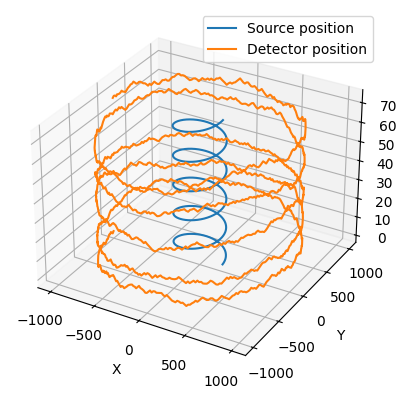

In [16]:
x1, y1, z1 = src_pos[:, 0], src_pos[:, 1], src_pos[:, 2]
x2, y2, z2 = corrected_det_pos[:, 0], corrected_det_pos[:, 1], corrected_det_pos[:, 2]

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot(x1, y1, z1, label='Source position')
ax.plot(x2, y2, z2, label='Detector position')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

ax.legend()
plt.show()

We also define the image geometry. Each voxel is inside the field of view of projections from 4 revolutions in the full dataset, but since we didn't load all the data, only parts of the reconstructed volume will show the sample in full resolution. The variable $\verb!center_z!$ can be increased to around $30$, but in that case the top part of the reconstructed volume will not have full resolution.

In [32]:
magnification = np.abs((obj_to_det + src_to_obj) / src_to_obj)

voxel_size = pixel_size_w/magnification

voxel_num_x = pixel_num_w
voxel_num_y = pixel_num_w
voxel_num_z = np.round(height_per_step * num_proj_subset / voxel_size).astype(int)

ig = ImageGeometry(
    voxel_num_x, voxel_num_y, voxel_num_z,
    voxel_size, voxel_size, voxel_size,
    center_z=voxel_size*voxel_num_z//2
)

To display the geometric setup using CIL's show_geometry, we can extract the geometric information from one projection, and plot

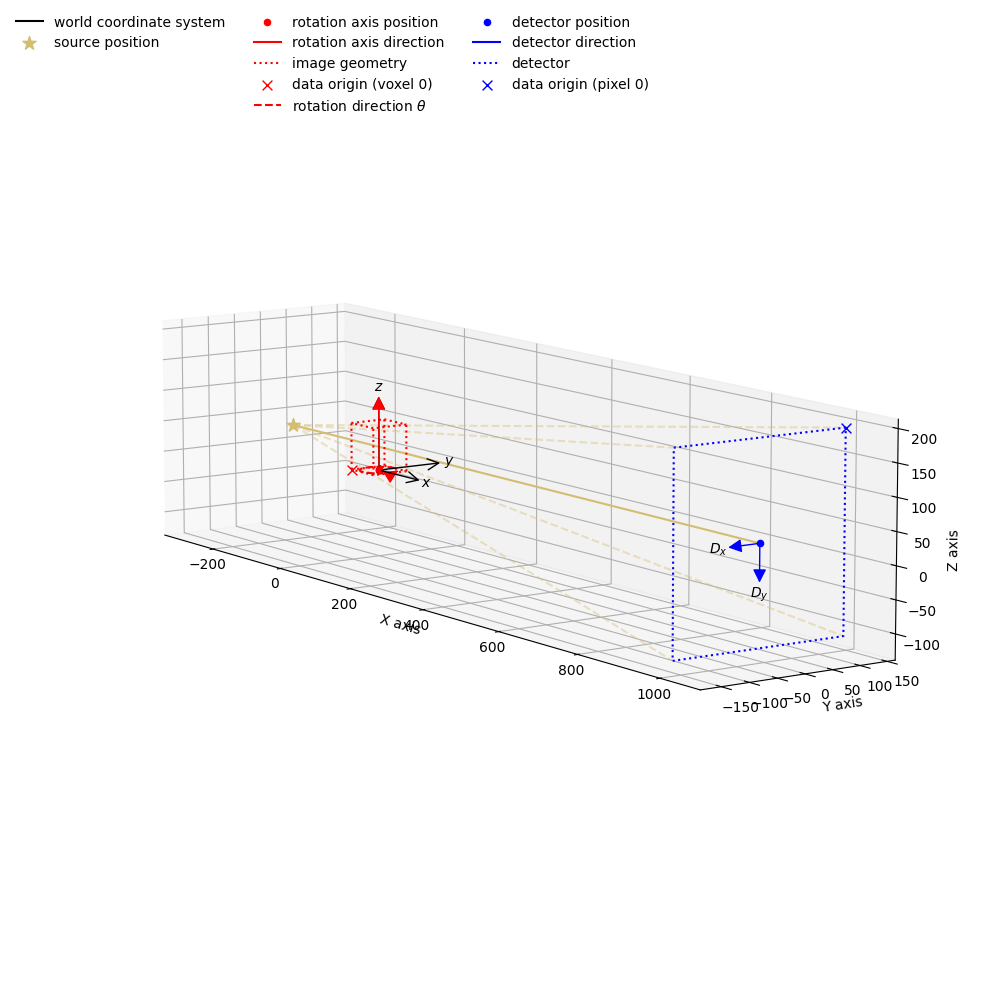

In [33]:
index = num_proj_subset//2
ag_index = AcquisitionGeometry.create_Cone3D(
    src_pos[index],
    det_pos[index],
    det_x[index],
    det_y[index],
).set_panel(
    (pixel_num_w, pixel_num_h), (pixel_size_w, pixel_size_h)
).set_angles([index*angle_step])
show_geometry(ag_index, ig, grid=True, elevation=10)

## Flat field and reconstruction

We define the AcquisitionData object, and use CIL's $\verb!Normaliser!$ and $\verb!TransmissionAbsorptionConverter!$ to obtain the absorption images

In [34]:
ad = AcquisitionData(array=data, geometry=ag)
ad = Normaliser(flat_field=flat_field)(ad)
ad = TransmissionAbsorptionConverter(accelerated=False)(ad)

The reconstruction is carried out using ASTRA's implementation of the FDK algorithm.

In [35]:
ad.reorder(order='astra')
fbp = FBP(image_geometry=ig, acquisition_geometry=ad.geometry)
fbp.set_input(ad)
recon = fbp.get_output()

In [ ]:
islicer(recon, minmax=(0.,0.03))

### Conclusion

To our knowledge, this is the first helical scan carried out using CIL.

Helical CT-scans are common in especially medical imaging, and as this example shows, some lab CT scanners (for example the NSI vorteX) also have helical geometry. Essentially all industrial CT scanners come with reconstruction software. The reconstruction technique is usually FDK with beam hardening artifact and ring corrections, but is to some extend a black box. This notebook shows that with CIL, the control is in the hands of the user — also for helical scans. For the example in this notebook, we were able to achieve a good quality reconstruction with FDK, but if additional regularization had been necessary, the geometric setup in CIL would be the same.